In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil1sharma/single-prediction-cat-or-dog")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'single-prediction-cat-or-dog' dataset.
Path to dataset files: /kaggle/input/single-prediction-cat-or-dog


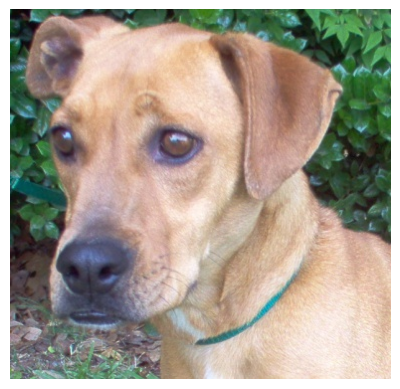

In [19]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# Combine the dataset path with the subfolder and file name
img_path = os.path.join(path, 'single_prediction', 'cat_or_dog_1.jpg')

# If the folder name is capitalized on Kaggle, use 'Single_prediction' instead:
if not os.path.exists(img_path):
    img_path = os.path.join(path, 'Single_prediction', 'cat_or_dog_1.jpg')

# Load and display the image
img = load_img(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest')
import os # Make sure os is imported at the top of this cell too!

# ... your ImageDataGenerator code ...

# Point it directly to the dog image in your dataset
img_path = os.path.join(path, 'single_prediction', 'cat_or_dog_2.jpg')
if not os.path.exists(img_path):
    img_path = os.path.join(path, 'Single_prediction', 'cat_or_dog_2.jpg')

img = load_img(img_path) # Now it will load the dog perfectly!
x = img_to_array(img)  # this is a Numpy array with shape (3, 150, 150)
x = x.reshape((1,) + x.shape)  # this is a Numpy array with shape (1, 3, 150, 150)

# the .flow() command below generates batches of randomly transformed images
# and saves the results to the `preview/` directory
# Create the preview directory so the generator has a place to save the images
os.makedirs('preview', exist_ok=True)
i = 0
for batch in datagen.flow(x, batch_size=1,
                          save_to_dir='preview', save_prefix='cat', save_format='jpeg'):
    i += 1
    if i > 20:
        break  # otherwise the generator would loop indefinitely

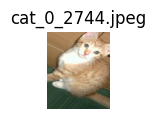

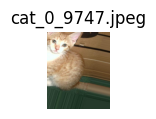

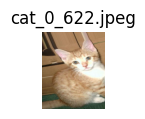

In [25]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# List all the generated images in your preview folder
preview_imgs = os.listdir('preview')

# Display the first 3 generated variations
for img_name in preview_imgs[:3]:
    img_path = os.path.join('preview', img_name)
    img = load_img(img_path)

    plt.figure(figsize=(1, 1))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()